# Prerequisite for experiment
Environment setup, package installation, function definition

## Set up environment

In [1]:
!pip install tqdm
!pip install transformers datasets
!pip install torchinfo

## Packages

In [2]:
import numpy as np
import torch
import torch.nn as nn
from datasets import Array3D, ClassLabel, Features, load_dataset
from matplotlib import pyplot
import matplotlib.pyplot as plt
from numpy import inf
from sklearn.utils.class_weight import compute_class_weight
from torchinfo import summary
from tqdm import tqdm
from torch.optim import AdamW
from transformers import ViTImageProcessor, ViTModel
from torch.optim import AdamW
from tqdm import tqdm
from datasets import load_dataset, Features, ClassLabel, Array3D




## download CIFAR10 dataset

In [3]:
# load cifar10
train_ds, test_ds = load_dataset('cifar10', split=['train[:5000]', 'test[:2000]'])

# split up training into training + validation
splits = train_ds.train_test_split(test_size=0.1)
train_ds = splits['train']
val_ds = splits['test']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Feature Extractor and Define Categories

(32, 32, 3)
automobile


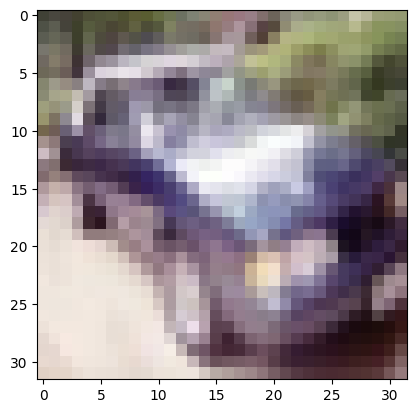

In [4]:
feature_extractor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')

chk = train_ds[67]
a = np.array(chk['img'])
print(a.shape)
cats = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


print(cats[chk['label']])
pyplot.imshow(a, cmap=pyplot.get_cmap('gray'))

## Process image

In [5]:
def preprocess_images(examples):
    # get batch of images
    images = examples['img']

    # convert to list of NumPy arrays of shape (C, H, W)
    images = [np.array(image, dtype=np.uint8) for image in images]
    images = [np.moveaxis(image, source=-1, destination=0) for image in images]

    # preprocess and add pixel_values
    inputs = feature_extractor(images=images)
    examples['pixel_values'] = inputs['pixel_values']
    return examples

In [6]:
# we need to define the features ourselves as both the img and pixel_values have a 3D shape
import datasets
from datasets import Features, ClassLabel, Array3D

features = Features({
    'label': ClassLabel(names=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']),
    'img': datasets.Image(decode=True),
    'pixel_values': Array3D(dtype="float32", shape=(3, 224, 224)),
})

preprocessed_train_ds = train_ds.map(preprocess_images, batched=True, features=features)
preprocessed_val_ds = val_ds.map(preprocess_images, batched=True, features=features)
preprocessed_test_ds = test_ds.map(preprocess_images, batched=True, features=features)

Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [7]:
# set format to PyTorch
preprocessed_train_ds.set_format('torch', columns=['pixel_values', 'label'])
preprocessed_val_ds.set_format('torch', columns=['pixel_values', 'label'])
preprocessed_test_ds.set_format('torch', columns=['pixel_values', 'label'])

In [8]:
# check dataset
preprocessed_train_ds

Dataset({
    features: ['label', 'img', 'pixel_values'],
    num_rows: 4500
})

## Dataloader for training, validation, testing

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# create dataloaders
train_batch_size = 10
eval_batch_size = 10
train_dataloader = torch.utils.data.DataLoader(preprocessed_train_ds, batch_size=train_batch_size, shuffle=True, num_workers=2)
val_dataloader = torch.utils.data.DataLoader(preprocessed_val_ds, batch_size=eval_batch_size, num_workers=2)
test_dataloader = torch.utils.data.DataLoader(preprocessed_test_ds, batch_size=eval_batch_size, num_workers=2)
batch = next(iter(train_dataloader))

## Define Model
using pre-trained model

In [10]:
class ViTForImageClassification(nn.Module):
    def __init__(self, num_labels=10, last_n_layers=1):
        super(ViTForImageClassification, self).__init__()
        self.vit = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k', output_attentions=True )
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.vit.config.hidden_size, num_labels)
        self.num_labels = num_labels
        self.last_n_layers = last_n_layers

    def forward(self, pixel_values, return_attn=False):
        # outputs.attentions: tuple(len = num_layers), each [B, H, L, L]
        outputs = self.vit(pixel_values=pixel_values)

        cls = self.dropout(outputs.last_hidden_state[:, 0])
        logits = self.classifier(cls)

        if not return_attn:
            return logits

        # last layer's attention
        attentions = outputs.attentions[-self.last_n_layers:]     # list/tuple of [B, H, L, L]
        attn_stack = torch.stack(attentions, dim=0)               # [N, B, H, L, L]
        N, B, H, L, _ = attn_stack.shape

        # reshape to"layer × head" matrix：[B, N*H, L, L]
        attn_stack = attn_stack.permute(1, 0, 2, 3, 4)            # [B, N, H, L, L]
        attn_matrix = attn_stack.reshape(B, N * H, L, L)

        return logits, attn_matrix


## Compute class weights in order to handle class imbalance

In [11]:
# extract labels to list
labels = preprocessed_train_ds["label"]       # list
labels = np.array(labels).ravel()             # make sure it's 1D

class_wts = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels,
)

# transform into tensor
weights = torch.tensor(class_wts, dtype=torch.float, device=device)

cross_entropy = nn.CrossEntropyLoss(weight=weights)

## Define Decorrelation loss

In [12]:
def decorrelation_loss(attn_matrix, eps=1e-8):
    B, K, L, _ = attn_matrix.shape
    X = attn_matrix.reshape(B, K, L * L)   # [B, K, D]

    # for every attention hea's vector, normalize in order to avoid 0 norm
    X_norm = X / (X.norm(dim=-1, keepdim=True) + eps)    # [B, K, D]

    # Compute cosine similarity matrix S = X_norm @ X_norm^T
    S = torch.matmul(X_norm, X_norm.transpose(-1, -2))  # [B, K, K]

    # off-diagonal
    eye = torch.eye(K, device=X.device).unsqueeze(0)     # [1, K, K]
    S = S * (1.0 - eye)

    # ReLU, only preserve positive similarity
    S_pos = torch.relu(S)

    # Compute Frobenius norm and do batch normalization
    frob = torch.norm(S_pos, dim=(1, 2))  # [B]
    loss = frob.mean()

    return loss


## Define Training and evaluating funcitons

In [13]:
"""
Define batch training function for each epoch
"""
def train(model, optimizer, lambda_decorr=0.1):
    model.train()
    total_loss = 0.0
    total_ce_loss = 0.0
    total_decorr_loss = 0.0
    total_preds = []

    for step, batch in enumerate(train_dataloader):

        if step % 50 == 0 and step != 0:
            print('  Batch {:>5,}  of  {:>5,}.'.format(step, len(train_dataloader)))

        lbl, pix = batch.items()
        lbl, pix = lbl[1].to(device), pix[1].to(device)

        # extract logits and attention matrix
        logits, attn_matrix = model(pix, return_attn=True)   # logits: [B, C], attn_matrix: [B, K, L, L]

        # classification loss
        ce_loss = cross_entropy(logits, lbl)

        # decorrelation loss
        decorr = decorrelation_loss(attn_matrix)

        # total loss
        loss = ce_loss + lambda_decorr * decorr

        # back propagation
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

        # record loss
        total_loss += loss.item()
        total_ce_loss += ce_loss.item()
        total_decorr_loss += decorr.item()

        preds_np = logits.detach().cpu().numpy()
        total_preds.append(preds_np)

    avg_loss = total_loss / len(train_dataloader)
    avg_ce = total_ce_loss / len(train_dataloader)
    avg_decorr = total_decorr_loss / len(train_dataloader)

    total_preds = np.concatenate(total_preds, axis=0)

    print(f"Train loss: {avg_loss:.4f} | CE: {avg_ce:.4f} | DeCorr: {avg_decorr:.4f}")

    return avg_loss, total_preds, avg_decorr


In [14]:
"""
Define evaluation function and epoch training function
"""
def eval():
    total_loss = 0
    model.eval() # prep model for evaluation
    for step,batch in enumerate(val_dataloader):
        lbl, pix = batch.items()
        lbl, pix = lbl[1].to(device), pix[1].to(device)

        # forward pass: compute predicted outputs by passing inputs to the model
        preds = model(pix)
        # calculate the loss
        loss = cross_entropy(preds, lbl)
        total_loss += loss.item()

    return total_loss / len(val_dataloader)

def training(model, optimizer, lambda_decorr=0, epochs=50):
    min_loss = float('inf')
    es = 0
    train_losses = []
    val_losses = []
    decorr_losses = []

    for epoch in range(epochs):
        print('\n Epoch {:} / {:}'.format(epoch + 1, epochs))

        # Train model
        train_loss, _, decorr_loss = train(model, optimizer, lambda_decorr)
        val_loss = eval()

        train_losses.append(train_loss)
        val_losses.append(val_loss[0] if isinstance(val_loss, tuple) else val_loss)  # if eval() returns a tuple, select the first element
        decorr_losses.append(decorr_loss)

        # Early Stopping
        if val_losses[-1] < min_loss:
            min_loss = val_losses[-1]
            es = 0
        else:
            es += 1
            if es > 4:
                print(f"Early stopping with train_loss: {train_loss} and val_loss: {val_losses[-1]}...")
                break

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        print(f'\n Training Loss: {train_loss:.3f}')
        print(f'\n Validation Loss: {val_losses[-1]:.3f}')

    # Plot learning curves
    plt.figure(figsize=(8,6))
    plt.plot(np.arange(1, len(train_losses) + 1), train_losses, label='Train Loss')
    plt.plot(np.arange(1, len(val_losses) + 1), val_losses, label='Validation Loss')
    plt.plot(np.arange(1, len(decorr_losses) + 1), decorr_losses, label='Decorrelation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Learning Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

# evaluation funciton after training, return predicted and ground-truth label
def evaluation(model):
    model.eval()
    y_pred = []
    y_true = []
    with torch.no_grad():
        for step, batch in tqdm(enumerate(test_dataloader), total = len(test_dataloader)):
            lbl, pix = batch.items()
            lbl, pix = lbl[1].to(device), pix[1].to(device)

            outputs = model(pix)
            outputs = torch.argmax(outputs, axis=1)
            y_pred.extend(outputs.cpu().detach().numpy())
            y_true.extend(lbl.cpu().detach().numpy())

    return y_pred, y_true


def evaluating(model):
    y_pred, y_true = evaluation(model)
    correct = np.array(y_pred) == np.array(y_true)
    accuracy = correct.sum() / len(correct)
    print("Accuracy of the model", accuracy)


## Prepare model for fine-tuning

In [15]:
def prepare_model_for_finetuning(defreeze_layers=1, lambda_decorr=0, num_labels=10, device='cuda'):
    model = ViTForImageClassification(num_labels=num_labels, last_n_layers=defreeze_layers)

    # freeze all parameters
    for param in model.vit.parameters():
        param.requires_grad = False

    # use defreeze_layers to defreeze the last n layers of transformer encoder
    num_layers = len(model.vit.encoder.layer)
    for i in range(num_layers - defreeze_layers, num_layers):
        for param in model.vit.encoder.layer[i].parameters():
            param.requires_grad = True

    # defreeze classifier
    for param in model.classifier.parameters():
        param.requires_grad = True

    # put model into device
    model = model.to(device)

    return model, lambda_decorr

# Experiment Section
train and evaluate models

## Train model


 Epoch 1 / 50
  Batch    50  of    450.
  Batch   100  of    450.
  Batch   150  of    450.
  Batch   200  of    450.
  Batch   250  of    450.
  Batch   300  of    450.
  Batch   350  of    450.
  Batch   400  of    450.
Train loss: 0.2862 | CE: 0.2460 | DeCorr: 4.0178

 Training Loss: 0.286

 Validation Loss: 0.193

 Epoch 2 / 50
  Batch    50  of    450.
  Batch   100  of    450.
  Batch   150  of    450.
  Batch   200  of    450.
  Batch   250  of    450.
  Batch   300  of    450.
  Batch   350  of    450.
  Batch   400  of    450.
Train loss: 0.0934 | CE: 0.0732 | DeCorr: 2.0241

 Training Loss: 0.093

 Validation Loss: 0.207

 Epoch 3 / 50
  Batch    50  of    450.
  Batch   100  of    450.
  Batch   150  of    450.
  Batch   200  of    450.
  Batch   250  of    450.
  Batch   300  of    450.
  Batch   350  of    450.
  Batch   400  of    450.
Train loss: 0.0654 | CE: 0.0497 | DeCorr: 1.5691

 Training Loss: 0.065

 Validation Loss: 0.212

 Epoch 4 / 50
  Batch    50  of    450.

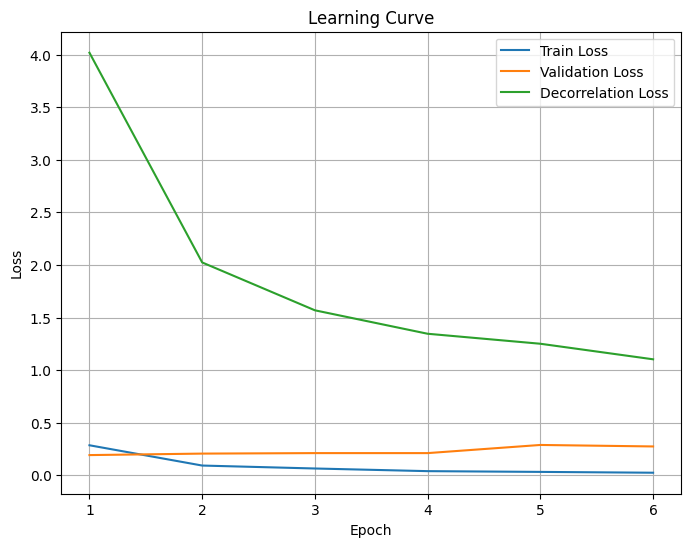

In [16]:
# parameters
defreeze_layer = 2
lambda_decorr = 0.01
epoch = 50

# prepare model
model, lambda_decorr = prepare_model_for_finetuning(defreeze_layer, lambda_decorr, num_labels=10)

# optimizer
optimizer = AdamW(model.parameters(), lr = 1e-3)


# training
training(model, optimizer, lambda_decorr, epoch)

## Test model

In [18]:
evaluating(model)

100%|██████████| 200/200 [00:11<00:00, 18.03it/s]

Accuracy of the model 0.953


## Summary of the model

In [19]:
summary(model)

Layer (type:depth-idx)                                  Param #
ViTForImageClassification                               --
├─ViTModel: 1-1                                         --
│    └─ViTEmbeddings: 2-1                               152,064
│    │    └─ViTPatchEmbeddings: 3-1                     (590,592)
│    │    └─Dropout: 3-2                                --
│    └─ViTEncoder: 2-2                                  --
│    │    └─ModuleList: 3-3                             85,054,464
│    └─LayerNorm: 2-3                                   (1,536)
│    └─ViTPooler: 2-4                                   --
│    │    └─Linear: 3-4                                 (590,592)
│    │    └─Tanh: 3-5                                   --
├─Dropout: 1-2                                          --
├─Linear: 1-3                                           7,690
Total params: 86,396,938
Trainable params: 14,183,434
Non-trainable params: 72,213,504

## CIFAR100

## Preparation for CIFAR100, including function implementation, data loader




In [16]:
# Define train function
def train_cifar100(model, optimizer, lambda_decorr=0.1):
    model.train()
    total_loss = 0.0
    total_ce_loss = 0.0
    total_decorr_loss = 0.0
    total_preds = []

    for step, batch in enumerate(train_dataloader):

        if step % 50 == 0 and step != 0:
            print('  Batch {:>5,}  of  {:>5,}.'.format(step, len(train_dataloader)))

        # Correctly extract 'fine_label' and 'pixel_values'
        lbl = batch['fine_label'].to(device)
        pix = batch['pixel_values'].to(device)

        logits, attn_matrix = model(pix, return_attn=True)
        ce_loss = cross_entropy(logits, lbl)
        decorr = decorrelation_loss(attn_matrix)
        loss = ce_loss + lambda_decorr * decorr

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        total_ce_loss += ce_loss.item()
        total_decorr_loss += decorr.item()

        preds_np = logits.detach().cpu().numpy()
        total_preds.append(preds_np)

    avg_loss = total_loss / len(train_dataloader)
    avg_ce = total_ce_loss / len(train_dataloader)
    avg_decorr = total_decorr_loss / len(train_dataloader)

    total_preds = np.concatenate(total_preds, axis=0)

    print(f"Train loss: {avg_loss:.4f} | CE: {avg_ce:.4f} | DeCorr: {avg_decorr:.4f}")

    return avg_loss, total_preds, avg_decorr

# Define eval_model function
def eval_model_cifar100(model):
    total_loss = 0
    model.eval()
    for step,batch in enumerate(val_dataloader):
        lbl = batch['fine_label'].to(device)
        pix = batch['pixel_values'].to(device)

        preds = model(pix)
        loss = cross_entropy(preds, lbl)
        total_loss += loss.item()

    return total_loss / len(val_dataloader)

# Define training function
def training_cifar100(model, optimizer, lambda_decorr=0, epochs=50):
    min_loss = float('inf')
    es = 0
    train_losses = []
    val_losses = []
    decorr_losses = []

    for epoch_num in range(epochs):
        print('\n Epoch {:} / {:}\n'.format(epoch_num + 1, epochs))

        train_loss, _, decorr_loss = train_cifar100(model, optimizer, lambda_decorr)
        val_loss = eval_model_cifar100(model)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        decorr_losses.append(decorr_loss)

        if val_losses[-1] < min_loss:
            min_loss = val_losses[-1]
            es = 0
        else:
            es += 1
            if es > 4:
                print(f"Early stopping with train_loss: {train_loss} and val_loss: {val_losses[-1]}...")
                break

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        print(f'\n Training Loss: {train_loss:.3f}')
        print(f'\n Validation Loss: {val_losses[-1]:.3f}')

    plt.figure(figsize=(8,6))
    plt.plot(np.arange(1, len(train_losses) + 1), train_losses, label='Train Loss')
    plt.plot(np.arange(1, len(val_losses) + 1), val_losses, label='Validation Loss')
    plt.plot(np.arange(1, len(decorr_losses) + 1), decorr_losses, label='Decorrelation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Learning Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

# Define evaluation function
def evaluation_cifar100(model):
    model.eval()
    y_pred = []
    y_true = []
    with torch.no_grad():
        for step, batch in tqdm(enumerate(test_dataloader), total = len(test_dataloader)):
            lbl = batch['fine_label'].to(device)
            pix = batch['pixel_values'].to(device)

            outputs = model(pix)
            outputs = torch.argmax(outputs, axis=1)
            y_pred.extend(outputs.cpu().detach().numpy())
            y_true.extend(lbl.cpu().detach().numpy())

    return y_pred, y_true

# Define compare_both_models function
def compare_both_models_for_cifar100(defreeze_layer=2, lambda_decorr_base=0, lambda_decorr_decorr=0.1, lr=1e-4):
  # Define the number of defrozen layers
  defreeze_layer = defreeze_layer
  cifar100_num_labels = 100

  # Set lambda_decorr_param_base to 0 for the base model
  lambda_decorr_param_base = lambda_decorr_base
  lambda_decorr_param_decorr = lambda_decorr_decorr

  # Call the prepare_model_for_finetuning function to create the base_model
  base_model, lambda_decorr_base = prepare_model_for_finetuning(
      defreeze_layers=defreeze_layer,
      lambda_decorr=lambda_decorr_param_base,
      num_labels=cifar100_num_labels # Use cifar100_num_labels for CIFAR100
  )

  # Re-train base model to get its learning curve (as requested)
  optimizer_base = AdamW(base_model.parameters(), lr=lr)
  print("\n--- Training Base Model ---")
  training_cifar100(base_model, optimizer_base, lambda_decorr_base, epoch)

  # Re-train the decorrelation model to get its learning curve (as requested)
  # First, re-initialize it to ensure a fresh start before retraining
  model_decorr, lambda_decorr_for_training = prepare_model_for_finetuning(
      defreeze_layer,
      lambda_decorr=lambda_decorr_param_decorr, # Use the original lambda_decorr for this model
      num_labels=cifar100_num_labels # 100 labels for CIFAR100
  )
  optimizer_decorr = AdamW(model_decorr.parameters(), lr=lr)
  print("\n--- Training Decorrelation Model ---")
  training_cifar100(model_decorr, optimizer_decorr, lambda_decorr_for_training, epoch)

  # Evaluate base model
  y_pred_base, y_true_base = evaluation_cifar100(base_model)
  correct_base = np.array(y_pred_base) == np.array(y_true_base)
  accuracy_base = correct_base.sum() / len(correct_base)
  print(f"\nAccuracy of the base model: {accuracy_base}")

  # Evaluate decorrelation model
  y_pred_decorr, y_true_decorr = evaluation_cifar100(model_decorr)
  correct_decorr = np.array(y_pred_decorr) == np.array(y_true_decorr)
  accuracy_decorr = correct_decorr.sum() / len(correct_decorr)
  print(f"\nAccuracy of the decorrelation model: {accuracy_decorr}")

# Execute the comparison
# compare_both_models(defreeze_layer, lambda_decorr_base, lambda_decorr_decorr)

In [17]:
def compare_both_models(defreeze_layer=2, lambda_decorr_base=0, lambda_decorr_decorr=0.1, lr=1e-4):
  # Define the number of defrozen layers
  defreeze_layer = defreeze_layer

  # Set lambda_decorr_param_base to 0 for the base model
  lambda_decorr_param_base = lambda_decorr_base
  lambda_decorr_param_decorr = lambda_decorr_decorr

  # Call the prepare_model_for_finetuning function to create the base_model
  base_model, lambda_decorr_base = prepare_model_for_finetuning(
      defreeze_layers=defreeze_layer,
      lambda_decorr=lambda_decorr_param_base,
      num_labels=cifar100_num_labels # Use cifar100_num_labels for CIFAR100
  )

  # Re-train base model to get its learning curve (as requested)
  optimizer_base = AdamW(base_model.parameters(), lr=lr)
  print("\n--- Training Base Model ---")
  training(base_model, optimizer_base, lambda_decorr_base, epoch)

  # Re-train the decorrelation model to get its learning curve (as requested)
  # First, re-initialize it to ensure a fresh start before retraining
  model_decorr, lambda_decorr_for_training = prepare_model_for_finetuning(
      defreeze_layer,
      lambda_decorr=lambda_decorr_param_decorr, # Use the original lambda_decorr for this model
      num_labels=cifar100_num_labels # 100 labels for CIFAR100
  )
  optimizer_decorr = AdamW(model_decorr.parameters(), lr=lr)
  print("\n--- Training Decorrelation Model ---")
  training(model_decorr, optimizer_decorr, lambda_decorr_for_training, epoch)

  # Evaluate base model
  y_pred_base, y_true_base = evaluation(base_model)
  correct_base = np.array(y_pred_base) == np.array(y_true_base)
  accuracy_base = correct_base.sum() / len(correct_base)
  print(f"\nAccuracy of the base model: {accuracy_base}")

  # Evaluate decorrelation model
  y_pred_decorr, y_true_decorr = evaluation(model_decorr)
  correct_decorr = np.array(y_pred_decorr) == np.array(y_true_decorr)
  accuracy_decorr = correct_decorr.sum() / len(correct_decorr)
  print(f"\nAccuracy of the decorrelation model: {accuracy_decorr}")

In [18]:
# define training function with different hyperparameters using CIFAR100
def train_decorr_model(defreeze_layer=2, lambda_decorr=0.1, lr=1e-3, epoch=50):
  model_decorr, lambda_decorr_for_training = prepare_model_for_finetuning(
      defreeze_layer,
      lambda_decorr=lambda_decorr, # Use the original lambda_decorr for this model
      num_labels=100 # 100 labels for CIFAR100
  )
  optimizer_decorr = AdamW(model_decorr.parameters(), lr=lr)
  print("\n--- Training Decorrelation Model ---")
  training_cifar100(model_decorr, optimizer_decorr, lambda_decorr_for_training, epoch)

   # Evaluate decorrelation model
  y_pred_decorr, y_true_decorr = evaluation(model_decorr)
  correct_decorr = np.array(y_pred_decorr) == np.array(y_true_decorr)
  accuracy_decorr = correct_decorr.sum() / len(correct_decorr)
  print(f"\nAccuracy of the decorrelation model: {accuracy_decorr}")

In [19]:
# Re-instantiate dataloaders to reflect CIFAR100's 'fine_label' key
# Assuming train_batch_size and eval_batch_size are defined globally (e.g., from original cell FXnYXHMzUTOe)
train_batch_size = 10
eval_batch_size = 10


# Define device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 1. Load CIFAR-100 dataset and define labels
train_ds, test_ds = load_dataset('cifar100', split=['train[:5000]', 'test[:2000]'])
splits = train_ds.train_test_split(test_size=0.1)
train_ds = splits['train']
val_ds = splits['test']

cifar100_labels = train_ds.features['fine_label'].names
print(f"Dynamically retrieved CIFAR-100 labels: {cifar100_labels[:5]}...")

# 2. Feature Extractor
feature_extractor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')

# 3. Process image function
def preprocess_images(examples):
    images = examples['img']
    images = [np.array(image, dtype=np.uint8) for image in images]
    images = [np.moveaxis(image, source=-1, destination=0) for image in images]
    inputs = feature_extractor(images=images)
    examples['pixel_values'] = inputs['pixel_values']
    return examples

# 4. Define features and preprocess datasets
import datasets  # 如果還沒導入的話
features = Features({
    'fine_label': ClassLabel(names=cifar100_labels),
    'img': datasets.Image(decode=True),  # 使用 Image 類型來處理 PIL Image
    'pixel_values': Array3D(dtype="float32", shape=(3, 224, 224)),
})

print("Features before mapping:", features)

preprocessed_train_ds = train_ds.map(preprocess_images, batched=True, features=features, remove_columns=['coarse_label'])
preprocessed_val_ds = val_ds.map(preprocess_images, batched=True, features=features, remove_columns=['coarse_label'])
preprocessed_test_ds = test_ds.map(preprocess_images, batched=True, features=features, remove_columns=['coarse_label'])

# 5. Set format to PyTorch
print("Preprocessed train_ds features before set_format:", preprocessed_train_ds.features)
preprocessed_train_ds.set_format('torch', columns=['pixel_values', 'fine_label'])
preprocessed_val_ds.set_format('torch', columns=['pixel_values', 'fine_label'])
preprocessed_test_ds.set_format('torch', columns=['pixel_values', 'fine_label'])
print("Preprocessed train_ds features after set_format:", preprocessed_train_ds.features)

# 6. Dataloaders for training, validation, testing (num_workers=0 for debugging)
train_dataloader = torch.utils.data.DataLoader(preprocessed_train_ds, batch_size=train_batch_size, shuffle=True, num_workers=0)
val_dataloader = torch.utils.data.DataLoader(preprocessed_val_ds, batch_size=eval_batch_size, num_workers=0)
test_dataloader = torch.utils.data.DataLoader(preprocessed_test_ds, batch_size=eval_batch_size, num_workers=0)
print("Example batch from train_dataloader keys:", next(iter(train_dataloader)).keys())

# 7. Compute class weights and define cross_entropy loss
labels = preprocessed_train_ds["fine_label"]
labels = np.array(labels).ravel()
from sklearn.utils.class_weight import compute_class_weight
class_wts = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels,
)
weights = torch.tensor(class_wts, dtype=torch.float, device=device)
cross_entropy = nn.CrossEntropyLoss(weight=weights)

Dynamically retrieved CIFAR-100 labels: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver']...
Features before mapping: {'fine_label': ClassLabel(names=['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'cra', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 

Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Preprocessed train_ds features before set_format: {'fine_label': ClassLabel(names=['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'cra', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 't

## Comparison


--- Training Base Model ---

 Epoch 1 / 50

  Batch    50  of    450.
  Batch   100  of    450.
  Batch   150  of    450.
  Batch   200  of    450.
  Batch   250  of    450.
  Batch   300  of    450.
  Batch   350  of    450.
  Batch   400  of    450.
Train loss: 3.6355 | CE: 3.6355 | DeCorr: 29.1384

 Training Loss: 3.635

 Validation Loss: 2.562

 Epoch 2 / 50

  Batch    50  of    450.
  Batch   100  of    450.
  Batch   150  of    450.
  Batch   200  of    450.
  Batch   250  of    450.
  Batch   300  of    450.
  Batch   350  of    450.
  Batch   400  of    450.
Train loss: 1.6931 | CE: 1.6931 | DeCorr: 28.1961

 Training Loss: 1.693

 Validation Loss: 1.330

 Epoch 3 / 50

  Batch    50  of    450.
  Batch   100  of    450.
  Batch   150  of    450.
  Batch   200  of    450.
  Batch   250  of    450.
  Batch   300  of    450.
  Batch   350  of    450.
  Batch   400  of    450.
Train loss: 0.6170 | CE: 0.6170 | DeCorr: 28.7176

 Training Loss: 0.617

 Validation Loss: 0.765

 Epo

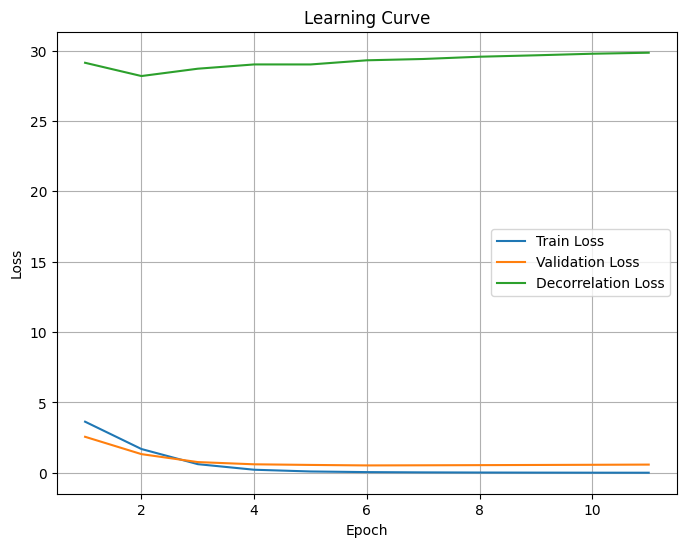


--- Training Decorrelation Model ---

 Epoch 1 / 50

  Batch    50  of    450.
  Batch   100  of    450.
  Batch   150  of    450.
  Batch   200  of    450.
  Batch   250  of    450.
  Batch   300  of    450.
  Batch   350  of    450.
  Batch   400  of    450.
Train loss: 3.6389 | CE: 3.6359 | DeCorr: 29.6398

 Training Loss: 3.639

 Validation Loss: 2.565

 Epoch 2 / 50

  Batch    50  of    450.
  Batch   100  of    450.
  Batch   150  of    450.
  Batch   200  of    450.
  Batch   250  of    450.
  Batch   300  of    450.
  Batch   350  of    450.
  Batch   400  of    450.
Train loss: 1.6782 | CE: 1.6754 | DeCorr: 28.6714

 Training Loss: 1.678

 Validation Loss: 1.325

 Epoch 3 / 50

  Batch    50  of    450.
  Batch   100  of    450.
  Batch   150  of    450.
  Batch   200  of    450.
  Batch   250  of    450.
  Batch   300  of    450.
  Batch   350  of    450.
  Batch   400  of    450.
Train loss: 0.6070 | CE: 0.6041 | DeCorr: 29.0430

 Training Loss: 0.607

 Validation Loss: 0.

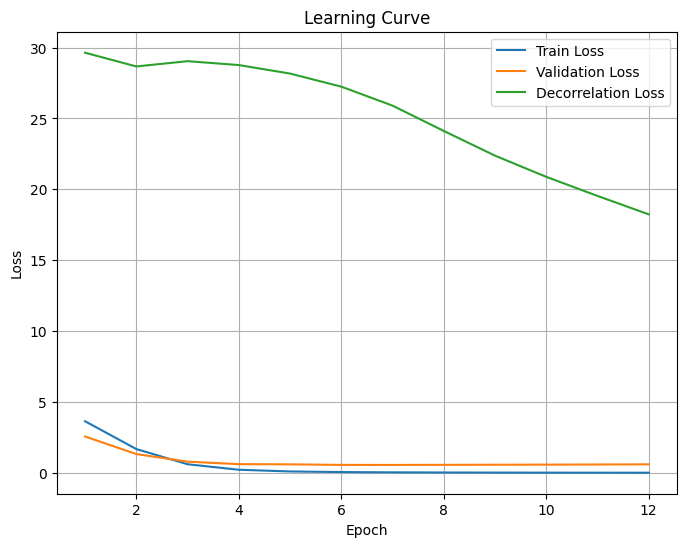

100%|██████████| 200/200 [00:11<00:00, 17.39it/s]



Accuracy of the base model: 0.8735


100%|██████████| 200/200 [00:11<00:00, 17.47it/s]


Accuracy of the decorrelation model: 0.8695


In [27]:
# hyper parameters
defreeze_layer=4
lambda_decorr_base=0
lambda_decorr_decorr= 1e-4
learning_rate = 1e-4

# Execute the comparison
compare_both_models_for_cifar100(defreeze_layer, lambda_decorr_base, lambda_decorr_decorr)

## Test with different parameters


--- Training Decorrelation Model ---

 Epoch 1 / 50

  Batch    50  of    450.
  Batch   100  of    450.
  Batch   150  of    450.
  Batch   200  of    450.
  Batch   250  of    450.
  Batch   300  of    450.
  Batch   350  of    450.
  Batch   400  of    450.
Train loss: 3.6230 | CE: 3.6201 | DeCorr: 29.6846

 Training Loss: 3.623

 Validation Loss: 2.544

 Epoch 2 / 50

  Batch    50  of    450.
  Batch   100  of    450.
  Batch   150  of    450.
  Batch   200  of    450.
  Batch   250  of    450.
  Batch   300  of    450.
  Batch   350  of    450.
  Batch   400  of    450.
Train loss: 1.6789 | CE: 1.6760 | DeCorr: 28.9330

 Training Loss: 1.679

 Validation Loss: 1.279

 Epoch 3 / 50

  Batch    50  of    450.
  Batch   100  of    450.
  Batch   150  of    450.
  Batch   200  of    450.
  Batch   250  of    450.
  Batch   300  of    450.
  Batch   350  of    450.
  Batch   400  of    450.
Train loss: 0.6011 | CE: 0.5981 | DeCorr: 29.1336

 Training Loss: 0.601

 Validation Loss: 0.

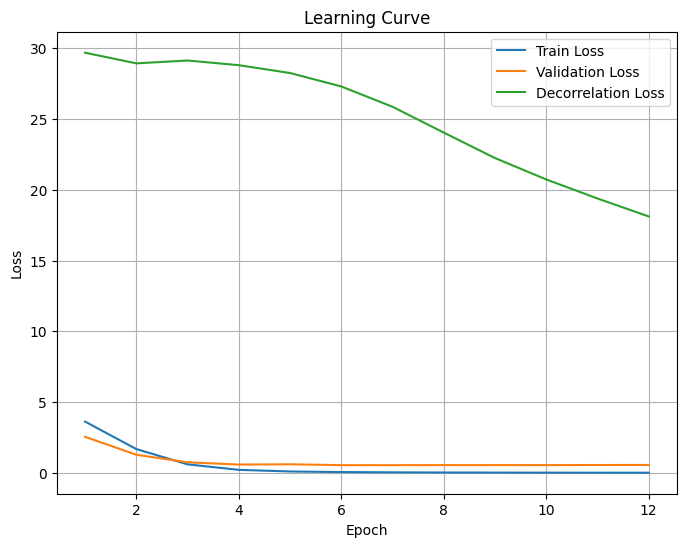

100%|██████████| 200/200 [00:11<00:00, 17.80it/s]


Accuracy of the decorrelation model: 0.866


In [30]:
defreeze_layer = 4
lambda_decorr = 1e-4
learning_rate = 1e-4

train_decorr_model(defreeze_layer, lambda_decorr, learning_rate)